In [1]:
import numpy as np
import pandas as pd
import os

# Use the actual competition folder if present (Kaggle standard).
# Fixes: wrong paths like ../input/train/train/ and ../input/test/test/ causing cv2.imread(None).
BASE_DIR = "../input/aerial-cactus-identification"
if not os.path.exists(BASE_DIR):
    # fallback for alternate mount (as described in prompt)
    BASE_DIR = "/kaggle/input/aerial-cactus-identification"

print("BASE_DIR:", BASE_DIR)
print("BASE_DIR contents:", os.listdir(BASE_DIR)[:10])



BASE_DIR: ../input/aerial-cactus-identification
BASE_DIR contents: ['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']


In [2]:
import cv2
from PIL import Image
from matplotlib import pyplot as plt



In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader



In [4]:
DATA_DIR = BASE_DIR + "/"
TRAIN_DIR = os.path.join(DATA_DIR, "train") + "/"
TEST_DIR = os.path.join(DATA_DIR, "test") + "/"
NAMES_DIR = os.path.join(DATA_DIR, "train.csv")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

print("TRAIN_DIR:", TRAIN_DIR, "exists:", os.path.exists(TRAIN_DIR))
print("TEST_DIR:", TEST_DIR, "exists:", os.path.exists(TEST_DIR))
print("NAMES_DIR:", NAMES_DIR, "exists:", os.path.exists(NAMES_DIR))
print("SAMPLE_SUB_PATH:", SAMPLE_SUB_PATH, "exists:", os.path.exists(SAMPLE_SUB_PATH))



TRAIN_DIR: ../input/aerial-cactus-identification/train/ exists: True
TEST_DIR: ../input/aerial-cactus-identification/test/ exists: True
NAMES_DIR: ../input/aerial-cactus-identification/train.csv exists: True
SAMPLE_SUB_PATH: ../input/aerial-cactus-identification/sample_submission.csv exists: True


In [5]:
# Quick sanity checks
print("Num train images:", len(os.listdir(TRAIN_DIR)))
print("Num test images:", len(os.listdir(TEST_DIR)))

train_names = pd.read_csv(NAMES_DIR)
print("train.csv shape:", train_names.shape)
train_names.head()




Num train images: 14176
Num test images: 3326
train.csv shape: (14175, 2)


,id,has_cactus
0,2de8f189f1dce439766637e75df0ee27.jpg,1
1,36704d250f236238e7f996812c48235d.jpg,1
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1
4,152491e0daf75c0e669400300ff7e645.jpg,1


has_cactus: 0


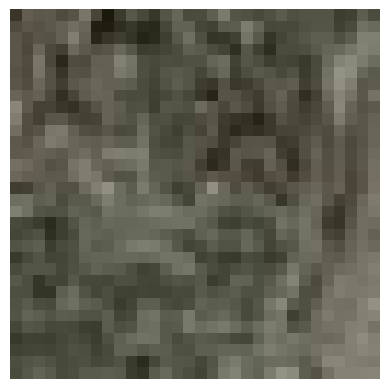

In [6]:
def show_image(index):
    image = Image.open(os.path.join(TRAIN_DIR, str(train_names["id"].iloc[index])))
    plt.imshow(image)
    plt.axis("off")
    print("has_cactus:", int(train_names["has_cactus"].iloc[index]))


show_image(20)




In [7]:
class HasCactusDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.img_names = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.img_names.iloc[idx, 0])

        image = cv2.imread(img_name)
        if image is None:
            raise FileNotFoundError(f"Could not read image: {img_name}")

        # Keep core logic, but ensure consistent scaling:
        # Previously ToTensor() was defined but never used; this fixes input range without changing architecture.
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        has_cactus = int(self.img_names.iloc[idx, 1])
        return image, has_cactus




(-0.5, 31.5, 31.5, -0.5)

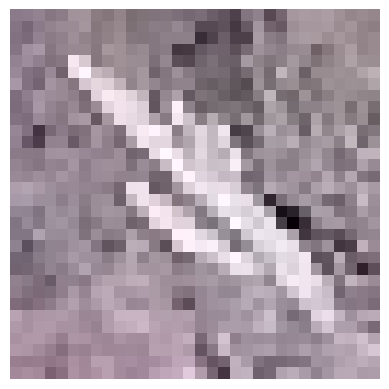

In [8]:
hasCactusDataset = HasCactusDataset(
    csv_file=NAMES_DIR,
    root_dir=TRAIN_DIR,
    transform=None,
)

plt.imshow(hasCactusDataset[19][0].permute(1, 2, 0).numpy())
plt.axis("off")



In [9]:
dataloader = DataLoader(
    hasCactusDataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)




In [10]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 10, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(10, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv3 = nn.Conv2d(16, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x


net = Net()



In [11]:
critation = nn.BCELoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)



In [12]:
# Training loop preserved (same epochs/optimizer/loss); only minor printing fix and dtype safety.
net.train()
for epoch in range(10):
    running_loss = 0.0
    print("epoch {} started...".format(epoch))
    for i, (image, label) in enumerate(dataloader):
        optimizer.zero_grad()

        inputs = image.float()
        label = torch.tensor(label, dtype=torch.float32).view(-1, 1)

        outputs = net(inputs)
        loss = critation(outputs.float(), label)
        loss.backward()
        optimizer.step()

        running_loss += float(loss.item())

    print(
        "epoch {} complete, loss={:.5f}".format(epoch, running_loss / max(1, (i + 1)))
    )

print("finished Training...")



epoch 0 started...


/tmp/ipykernel_11/1635918499.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label, dtype=torch.float32).view(-1, 1)


epoch 0 complete, loss=0.67892
epoch 1 started...
epoch 1 complete, loss=0.60983
epoch 2 started...
epoch 2 complete, loss=0.56731
epoch 3 started...
epoch 3 complete, loss=0.55678
epoch 4 started...
epoch 4 complete, loss=0.55504
epoch 5 started...
epoch 5 complete, loss=0.55297
epoch 6 started...
epoch 6 complete, loss=0.55065
epoch 7 started...
epoch 7 complete, loss=0.54671
epoch 8 started...
epoch 8 complete, loss=0.53934
epoch 9 started...
epoch 9 complete, loss=0.52513
finished Training...


In [13]:
# Prepare ordered test ids based on sample submission to ensure correct row count + order.
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
test_ids = sample_sub["id"].tolist()
print("sample_submission rows:", len(sample_sub))
print("first 5 test ids:", test_ids[:5])




sample_submission rows: 3325
first 5 test ids: ['09034a34de0e2015a8a28dfe18f423f6.jpg', '134f04305c795d6d202502c2ce3578f3.jpg', '41fad8d145e6c41868ce3617e30a2545.jpg', '35f8a11352c8d41b6231bb33d8d09f7e.jpg', 'b77dc902b035887cbbc01920ce0e3151.jpg']


In [14]:
class TestSet(Dataset):
    def __init__(self, root_dir, ids, transform=None):
        self.root_dir = root_dir
        self.ids = list(ids)
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_name = self.ids[idx]
        img_loc = os.path.join(self.root_dir, img_name)

        image = cv2.imread(img_loc)
        if image is None:
            raise FileNotFoundError(f"Could not read image: {img_loc}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        return image, img_name




In [15]:
testSet = TestSet(root_dir=TEST_DIR, ids=test_ids, transform=None)

testloader = DataLoader(
    testSet,
    batch_size=64,
    shuffle=False,  # critical for deterministic ordering
    num_workers=0,
    pin_memory=False,
)



batch images: torch.Size([64, 3, 32, 32]) batch names: 64
example name: 09034a34de0e2015a8a28dfe18f423f6.jpg


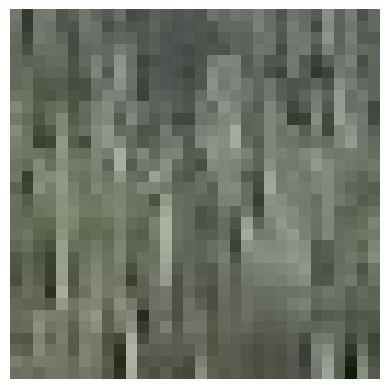

In [16]:
# Single batch sanity check
tstdata = next(iter(testloader))
print("batch images:", tstdata[0].shape, "batch names:", len(tstdata[1]))
plt.imshow(tstdata[0][0].permute(1, 2, 0).numpy())
plt.axis("off")
print("example name:", tstdata[1][0])



In [17]:
# Inference: set eval mode and no_grad (stability & speed). Core prediction semantics unchanged.
net.eval()
tst_outputs = []
tst_names = []

with torch.no_grad():
    for images, names in testloader:
        outputs = net(images.float()).view(-1).cpu().numpy().tolist()
        tst_outputs.extend(outputs)
        tst_names.extend(list(names))

print("Pred rows:", len(tst_outputs), "Name rows:", len(tst_names))



Pred rows: 3325 Name rows: 3325


In [18]:
# Build submission aligned to sample_submission ids to guarantee exact shape & ordering.
pred_map = dict(zip(tst_names, tst_outputs))
sub = sample_sub.copy()
sub["has_cactus"] = sub["id"].map(pred_map)

# Safety: ensure no missing predictions
missing = sub["has_cactus"].isna().sum()
print("Missing predictions:", missing)
if missing != 0:
    raise RuntimeError(
        f"Missing predictions for {missing} test ids; check paths/dataset loading."
    )

# Ensure probabilities in [0,1]
sub["has_cactus"] = sub["has_cactus"].clip(0.0, 1.0).astype(float)

sub.head()



Missing predictions: 0


,id,has_cactus
0,09034a34de0e2015a8a28dfe18f423f6.jpg,0.746895
1,134f04305c795d6d202502c2ce3578f3.jpg,0.789395
2,41fad8d145e6c41868ce3617e30a2545.jpg,0.797074
3,35f8a11352c8d41b6231bb33d8d09f7e.jpg,0.789150
4,b77dc902b035887cbbc01920ce0e3151.jpg,0.796651


In [19]:
sub.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", sub.shape)
print(sub.head())

Wrote submission.csv with shape: (3325, 2)
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg    0.746895
1  134f04305c795d6d202502c2ce3578f3.jpg    0.789395
2  41fad8d145e6c41868ce3617e30a2545.jpg    0.797074
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg    0.789150
4  b77dc902b035887cbbc01920ce0e3151.jpg    0.796651
